# Mount Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%pip install -e /content/drive/MyDrive/BUSI-XAI


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Obtaining file:///content/drive/MyDrive/BUSI-XAI
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for busi-xai (pyproject.toml) ... done
  Created wheel for busi-xai: filename=busi_xai-0.1.0-0.editable-py3-none-any.whl size=1176 sha256=c0e4dc7d7057aef47e588dec4cee82fb8e96710a99673ededf0aef6c0b830bc6
  Stored in directory: /tmp/pip-ephem-wheel-cache-c13uw5fa/wheels/bc/96/6a/14ad5b6a03036f6f181aa62fbcb8d63ac3b6cb1da04fcdcb1e
Successfully built busi-xai
  Attempting uninstall: busi-xai
    Found existing installation: busi-xai 0.1.0
    Uninstalling busi-xai-0.1.0:
      Successfully uninstalled busi-xai-0.1.0


# Imports, Initializations

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from busi_xai.config import RAW_DATA_DIR, INSPECTION_OUTPUT_DIR

classes = ["benign", "malignant"]
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)



# Class directory check

In [ ]:
for class_name in classes:
    class_dir = RAW_DATA_DIR / class_name

    if not class_dir.exists():
        raise FileNotFoundError(f"Missing directory: {class_dir}")

    print(f"{class_name:10s} -> {class_dir}")

    files = [p for p in class_dir.iterdir() if p.is_file()]

    print(f"{class_name} folder contains : {len(files):,} files")

benign     -> /content/drive/MyDrive/BUSI-XAI/data/raw/benign
benign folder contains : 891 files
malignant  -> /content/drive/MyDrive/BUSI-XAI/data/raw/malignant
malignant folder contains : 421 files


# Images & Masks

In [ ]:
def is_mask(path: Path) -> bool:
    return "_mask" in path.stem


def get_class_files(class_dir: Path):
    files = sorted(
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
    )

    masks = [p for p in files if is_mask(p)]
    images = [p for p in files if not is_mask(p)]

    return images, masks


dataset_summary = []

for class_name in classes:
    images, masks = get_class_files(RAW_DATA_DIR / class_name)

    dataset_summary.append({
        "class": class_name,
        "images": len(images),
        "masks": len(masks),
        "total_files": len(images) + len(masks),
    })

pd.DataFrame(dataset_summary)

,class,images,masks,total_files
0,benign,437,454,891
1,malignant,210,211,421


Total images: 647
class
benign       437
malignant    210
Name: count, dtype: int64
Images with masks: 647


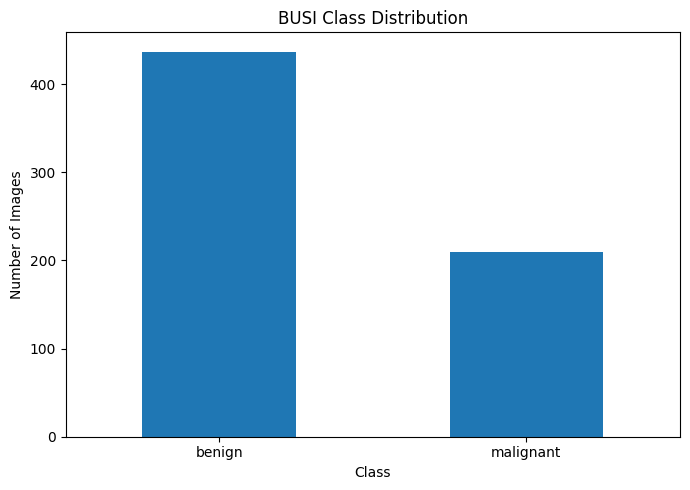

In [ ]:
records = []

for cls in classes:
    class_dir = RAW_DATA_DIR / cls
    # print("class directory: ",class_dir)
    for img_path in class_dir.glob("*"):
        # print("image Path: ", img_path)
        if img_path.suffix.lower() not in [".png", ".jpg", ".jpeg"]:
            continue

        # BUSI masks typically have "_mask" in their filename
        if "_mask" in img_path.stem:
            continue

        mask_path = class_dir / f"{img_path.stem}_mask{img_path.suffix}"

        records.append({
            "class": cls,
            "image": img_path,
            "mask": mask_path if mask_path.exists() else None
        })

df = pd.DataFrame(records)

print("Total images:", len(df))
print(df["class"].value_counts())
print("Images with masks:", df["mask"].notna().sum())


plt.figure(figsize=(7, 5))
df["class"].value_counts().reindex(classes).plot(
    kind="bar"
)
plt.title("BUSI Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Lesion area percentage

       area_percentage
count       647.000000
mean          9.302782
std           9.809132
min           0.212314
25%           2.125545
50%           5.580674
75%          12.893632
max          56.292422


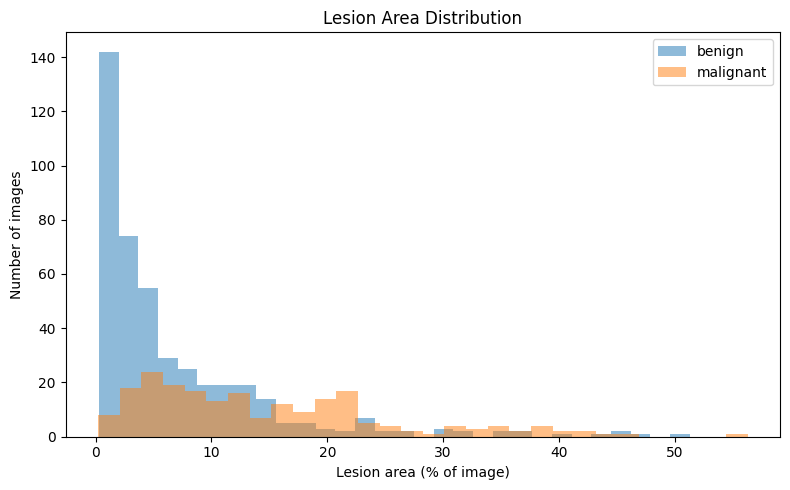

In [ ]:
areas = []

for _, row in df[df["mask"].notna()].iterrows():

    mask = np.array(Image.open(row["mask"]).convert("L"))

    # Any non-zero pixel is considered lesion
    lesion_pixels = np.count_nonzero(mask)

    total_pixels = mask.size

    area_percentage = (lesion_pixels / total_pixels) * 100

    areas.append({
        "class": row["class"],
        "area_percentage": area_percentage
    })

area_df = pd.DataFrame(areas)

print(area_df.describe())

plt.figure(figsize=(8, 5))

for cls in classes:
    values = area_df.loc[
        area_df["class"] == cls,
        "area_percentage"
    ]

    plt.hist(
        values,
        bins=30,
        alpha=0.5,
        label=cls
    )

plt.title("Lesion Area Distribution")
plt.xlabel("Lesion area (% of image)")
plt.ylabel("Number of images")
plt.legend()
plt.tight_layout()
plt.show()

# Mask Overlays

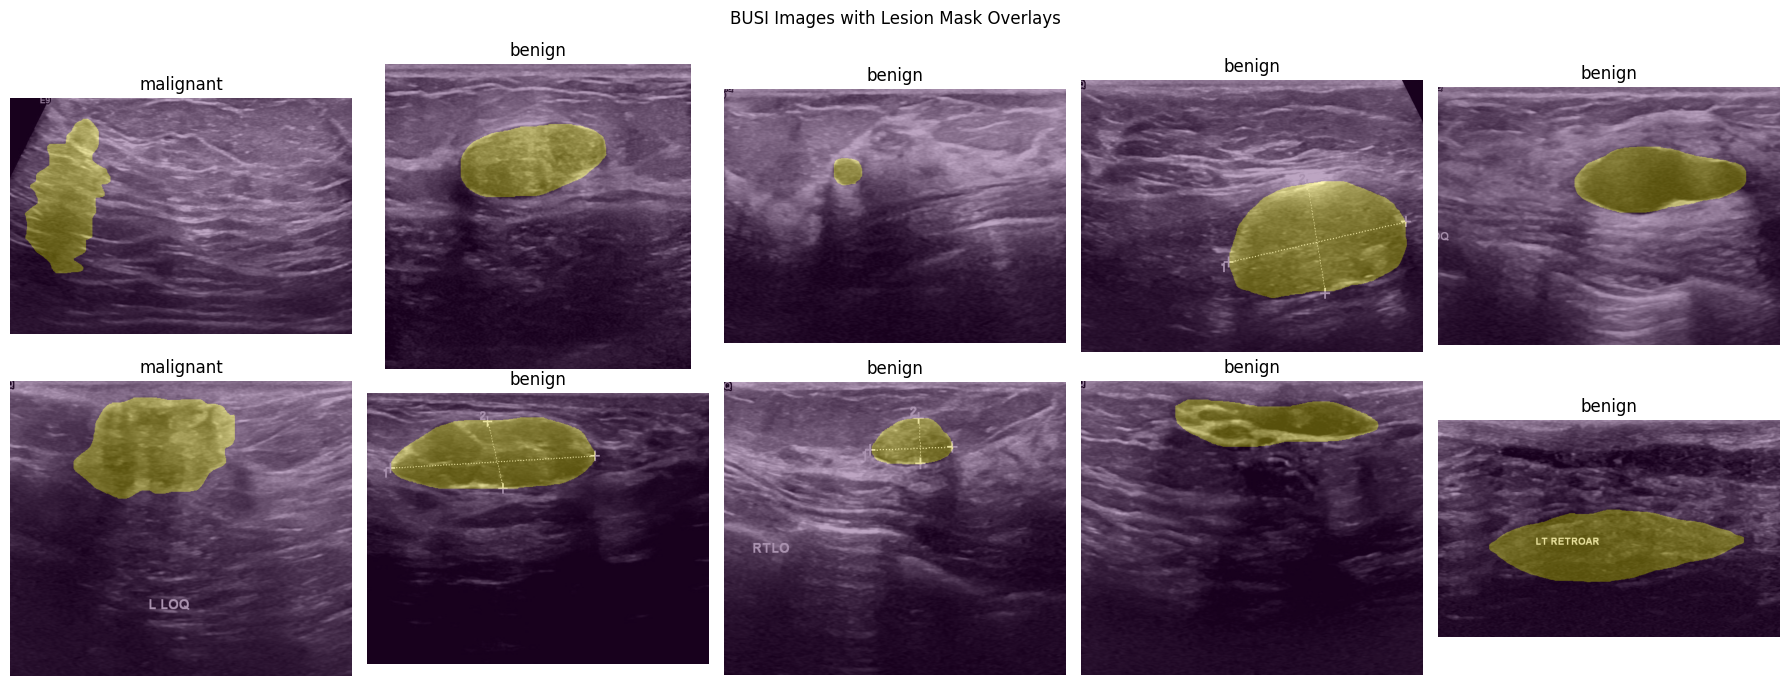

In [ ]:
sample_df = df[df["mask"].notna()].sample(
    n=min(10, len(df)),
    random_state=42
)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for ax, (_, row) in zip(axes, sample_df.iterrows()):

    image = np.array(Image.open(row["image"]).convert("RGB"))
    mask = np.array(Image.open(row["mask"]).convert("L"))

    ax.imshow(image)

    # Transparent mask overlay
    ax.imshow(
        mask > 0,
        alpha=0.35
    )

    ax.set_title(row["class"])
    ax.axis("off")

plt.suptitle("BUSI Images with Lesion Mask Overlays")
plt.tight_layout()
plt.show()

# Images dimensions

In [ ]:
def inspect_image(path: Path) -> dict:
    with Image.open(path) as image:
        array = np.asarray(image)

        return {
            "path": str(path),
            "filename": path.name,
            "width": image.width,
            "height": image.height,
            "channels": len(image.getbands()),
            "mode": image.mode,
            "dtype": array.dtype,
            "min": array.min(),
            "max": array.max(),
            "mean": array.mean(),
            "std": array.std(),
        }

image_records = []

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)

    for image_path in images:
        record = inspect_image(image_path)
        record["class"] = class_name
        image_records.append(record)

images_df = pd.DataFrame(image_records)

images_df.head()

,path,filename,width,height,channels,mode,dtype,min,max,mean,std,class
0,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,benign (1).png,562,471,3,RGB,uint8,0,255,132.375146,58.393189,benign
1,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,benign (10).png,683,585,3,RGB,uint8,0,255,103.240733,58.324293,benign
2,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,benign (100).png,323,473,3,RGB,uint8,0,255,90.107849,67.727781,benign
3,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,benign (101).png,563,473,3,RGB,uint8,0,255,103.225690,57.230160,benign
4,/content/drive/MyDrive/BUSI-XAI/data/raw/benig...,benign (102).png,634,610,3,RGB,uint8,0,243,54.337482,37.877145,benign


In [ ]:
dimension_counts = (
    images_df
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

dimension_counts.head(20)

,width,height,count
175,557,465,6
249,564,469,4
46,465,390,3
56,469,394,3
490,777,578,3
64,473,389,3
484,775,587,3
250,564,470,3
149,555,468,3
474,772,574,3


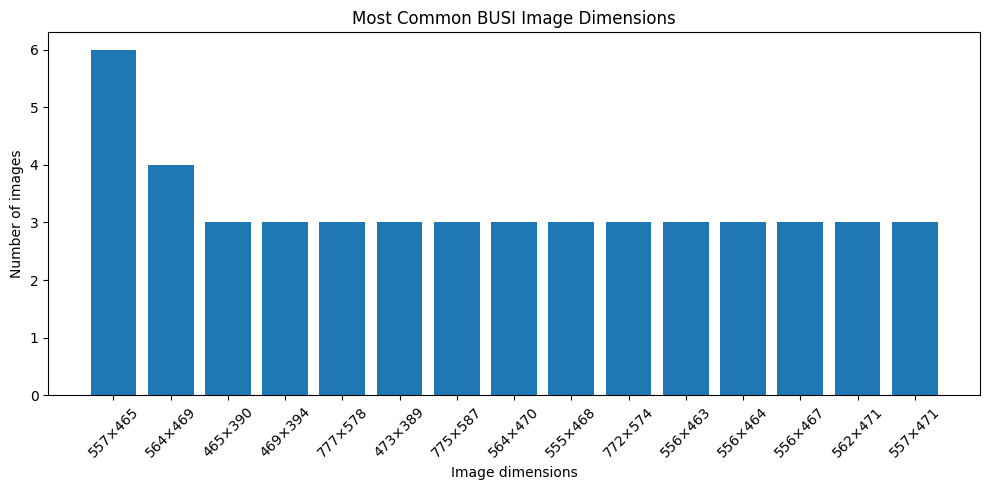

In [ ]:
top_dimensions = dimension_counts.head(15)

labels = [
    f"{w}×{h}"
    for w, h in zip(top_dimensions["width"], top_dimensions["height"])
]

plt.figure(figsize=(10, 5))
plt.bar(labels, top_dimensions["count"])
plt.xlabel("Image dimensions")
plt.ylabel("Number of images")
plt.title("Most Common BUSI Image Dimensions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Images channels & modes

In [ ]:
print("Image modes:")
print(images_df["mode"].value_counts())

print("\nChannel counts:")
print(images_df["channels"].value_counts())

print("\nData types:")
print(images_df["dtype"].value_counts())

Image modes:
mode
RGB    647
Name: count, dtype: int64

Channel counts:
channels
3    647
Name: count, dtype: int64

Data types:
dtype
uint8    647
Name: count, dtype: int64


# Mask counts per image

In [ ]:
def get_mask_paths(image_path: Path):
    return sorted(
        image_path.parent.glob(f"{image_path.stem}_mask*.png")
    )


mask_count_records = []

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)

    for image_path in images:
        masks = get_mask_paths(image_path)

        mask_count_records.append({
            "class": class_name,
            "image": image_path.name,
            "mask_count": len(masks),
        })

mask_counts_df = pd.DataFrame(mask_count_records)

mask_counts_df["mask_count"].value_counts().sort_index()

,count
mask_count,
1,630
2,16
3,1


In [ ]:
pd.crosstab(
    mask_counts_df["class"],
    mask_counts_df["mask_count"]
)

mask_count,1,2,3
class,,,
benign,421,15,1
malignant,209,1,0


# Find missing masks

In [ ]:
missing_masks = mask_counts_df[
    mask_counts_df["mask_count"] == 0
]

print(f"Images without masks: {len(missing_masks)}")

missing_masks.head(20)

Images without masks: 0


,class,image,mask_count


In [ ]:
multiple_masks = mask_counts_df[
    mask_counts_df["mask_count"] > 1
]

print(f"Images with multiple masks: {len(multiple_masks)}")

multiple_masks.head(20)

Images with multiple masks: 17


,class,image,mask_count
2,benign,benign (100).png,2
71,benign,benign (163).png,2
82,benign,benign (173).png,2
91,benign,benign (181).png,2
106,benign,benign (195).png,3
167,benign,benign (25).png,2
240,benign,benign (315).png,2
274,benign,benign (346).png,2
333,benign,benign (4).png,2
361,benign,benign (424).png,2


# Verify mask dimensions

In [ ]:
mask_records = []

for class_name in classes:
    _, masks = get_class_files(RAW_DATA_DIR / class_name)

    for mask_path in masks:
        with Image.open(mask_path) as mask:
            array = np.asarray(mask)

            mask_records.append({
                "class": class_name,
                "filename": mask_path.name,
                "width": mask.width,
                "height": mask.height,
                "mode": mask.mode,
                "dtype": array.dtype,
                "min": array.min(),
                "max": array.max(),
                "unique_values": len(np.unique(array)),
            })

masks_df = pd.DataFrame(mask_records)

masks_df.head()

,class,filename,width,height,mode,dtype,min,max,unique_values
0,benign,benign (1)_mask.png,562,471,1,bool,False,True,2
1,benign,benign (10)_mask.png,683,585,1,bool,False,True,2
2,benign,benign (100)_mask.png,323,473,1,bool,False,True,2
3,benign,benign (100)_mask_1.png,323,473,1,bool,False,True,2
4,benign,benign (101)_mask.png,563,473,1,bool,False,True,2


In [ ]:
mismatch_records = []

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)

    for image_path in images:
        with Image.open(image_path) as image:
            image_size = image.size

        for mask_path in get_mask_paths(image_path):
            with Image.open(mask_path) as mask:
                mask_size = mask.size

            if image_size != mask_size:
                mismatch_records.append({
                    "class": class_name,
                    "image": image_path.name,
                    "mask": mask_path.name,
                    "image_size": image_size,
                    "mask_size": mask_size,
                })

print(f"Dimension mismatches: {len(mismatch_records)}")

pd.DataFrame(mismatch_records)

Dimension mismatches: 0


""


# Check mask validity

In [ ]:
unique_mask_values = (
    masks_df["unique_values"]
    .value_counts()
    .sort_index()
)

unique_mask_values

,count
unique_values,
2,665


In [ ]:
all_mask_values = set()

for class_name in classes:
    _, masks = get_class_files(RAW_DATA_DIR / class_name)

    for mask_path in masks:
        array = np.asarray(Image.open(mask_path).convert("L"))
        all_mask_values.update(np.unique(array).tolist())

print("Unique mask pixel values:")
print(sorted(all_mask_values))

Unique mask pixel values:
[0, 255]


# Detect empty masks

In [ ]:
empty_masks = []

for class_name in classes:
    _, masks = get_class_files(RAW_DATA_DIR / class_name)

    for mask_path in masks:
        mask = np.asarray(Image.open(mask_path).convert("L"))

        if not np.any(mask > 0):
            empty_masks.append({
                "class": class_name,
                "mask": mask_path.name,
            })

print(f"Empty masks: {len(empty_masks)}")

pd.DataFrame(empty_masks)

Empty masks: 0


""


# Visual inspection

In [ ]:
def show_sample(image_path: Path, mask_path: Path):
    image = np.asarray(Image.open(image_path).convert("RGB"))
    mask = np.asarray(Image.open(mask_path).convert("L")) > 0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Mask")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(mask, alpha=0.35)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)

    sample_images = rng.choice(
        images,
        size=min(5, len(images)),
        replace=False,
    )

    for image_path in sample_images:
        masks = get_mask_paths(image_path)

        if masks:
            show_sample(image_path, masks[0])

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for _, row in multiple_masks.head(5).iterrows():

    image_path = RAW_DATA_DIR / row["class"] / row["image"]
    masks = get_mask_paths(image_path)

    print(f"\n{image_path.name}")

    for mask_path in masks:
        show_sample(image_path, mask_path)

Output hidden; open in https://colab.research.google.com to view.

# Check duplicate images

In [ ]:
import hashlib


def file_hash(path: Path) -> str:
    hasher = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            hasher.update(chunk)

    return hasher.hexdigest()


hash_records = []

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)

    for image_path in images:
        hash_records.append({
            "class": class_name,
            "image": image_path.name,
            "hash": file_hash(image_path),
        })

hash_df = pd.DataFrame(hash_records)

duplicates = hash_df[
    hash_df.duplicated("hash", keep=False)
].sort_values("hash")

print(f"Images involved in exact duplicates: {len(duplicates)}")

duplicates

Images involved in exact duplicates: 2


,class,image,hash
371,benign,benign (433).png,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...
488,malignant,malignant (145).png,058e7538fa53b2bd8b87500ff47721c84ec442dc964d9d...


## Generate one final inspection report

In [ ]:
class_counts = {}

for class_name in classes:
    images, _ = get_class_files(RAW_DATA_DIR / class_name)
    class_counts[class_name] = len(images)

counts = pd.Series(class_counts)

report = {
    "total_images": len(images_df),
    "total_masks": len(masks_df),
    "benign_images": class_counts.get("benign", 0),
    "malignant_images": class_counts.get("malignant", 0),
    "images_without_masks": len(missing_masks),
    "images_with_multiple_masks": len(multiple_masks),
    "empty_masks": len(empty_masks),
    "image_mask_dimension_mismatches": len(mismatch_records),
    "exact_duplicate_images": len(duplicates),
}

pd.Series(report, name="value")

,value
total_images,647
total_masks,665
benign_images,437
malignant_images,210
images_without_masks,0
images_with_multiple_masks,17
empty_masks,0
image_mask_dimension_mismatches,0
exact_duplicate_images,2


In [ ]:
INSPECTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.Series(report).to_csv(
    INSPECTION_OUTPUT_DIR / "dataset_inspection_summary.csv"
)

images_df.to_csv(
    INSPECTION_OUTPUT_DIR / "image_properties.csv",
    index=False,
)

masks_df.to_csv(
    INSPECTION_OUTPUT_DIR / "mask_properties.csv",
    index=False,
)

area_df.to_csv(
    INSPECTION_OUTPUT_DIR / "lesion_area.csv",
    index=False,
)

print(f"Reports saved to: {INSPECTION_OUTPUT_DIR}")

Reports saved to: /content/drive/MyDrive/BUSI-XAI/output/inspection
